In [1]:
# Download vector PhyloPic icons used in the comparison figure.
from pathlib import Path
from urllib.request import urlretrieve

icons_dir = Path("icons")
icons_dir.mkdir(parents=True, exist_ok=True)

icon_urls = {
    "spider": "https://images.phylopic.org/images/882a9d18-5724-44a9-b439-1b2686339a00/vector.svg",
    "insect": "https://images.phylopic.org/images/58eda733-f5dd-4a4d-8008-c85a333570b0/vector.svg",
    "fish": "https://images.phylopic.org/images/381e7e19-bb44-4432-85ce-627f05d159a3/vector.svg",
    "frog": "https://images.phylopic.org/images/c387bde8-a9de-4101-928b-e99f2a7a33e5/vector.svg",
    "bird": "https://images.phylopic.org/images/f9095d81-49c1-433d-bb92-4858fd48ce0d/vector.svg",
}

for name, url in icon_urls.items():
    destination = icons_dir / f"{name}.svg"
    urlretrieve(url, destination)
    print(f"Downloaded {destination}")

Downloaded icons/spider.svg
Downloaded icons/insect.svg
Downloaded icons/fish.svg
Downloaded icons/frog.svg
Downloaded icons/bird.svg


Cylinder trial table:
   trial channel     M_obs  signal_rate         f         M_sig  valid
0      1     Ch2  8.546660     9.745342  0.009635    515.472600   True
1      1     Ch3  8.352764     0.981366  0.000970   4886.724839   True
2      1     Ch4  7.555755     4.161491  0.004114    961.445295   True
3      3     Ch2  5.227565     0.174402  0.000172   9356.791128   True
4      3     Ch3  3.558230     0.485232  0.000480   -114.256863  False
5      3     Ch4  7.572332     0.233474  0.000231  17148.005460   True
6      4     Ch2  0.158096     0.087622  0.000087 -39897.059134  False
7      4     Ch4 -0.103040     0.051460  0.000051 -73068.604859  False
8      5     Ch2  3.042832     0.391549  0.000387  -1473.803630  False
9      5     Ch4  2.897411     0.108451  0.000107  -6686.634163  False

Summary mode: median
Summary M_sig = 4886.725
summary M_sig = 4886.725


/var/folders/pg/rkmvtptx175d4dsj5fd6w4d40000gp/T/ipykernel_58802/2277895013.py:359: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


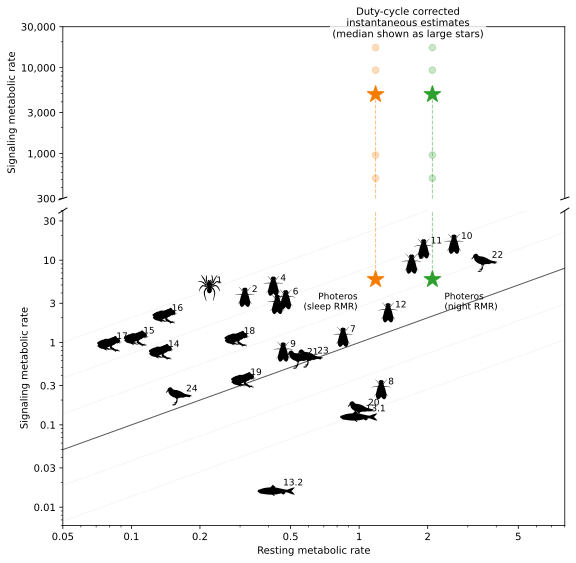

In [2]:
import math
from functools import lru_cache
from pathlib import Path
import re
import xml.etree.ElementTree as ET

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.path import Path as MplPath

try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
    set_matplotlib_formats("svg")
except ImportError:
    pass

try:
    from svgpath2mpl import parse_path
except ImportError as exc:
    raise ImportError(
        "Install svgpath2mpl to render vector icons, then rerun this cell. "
        "For conda: conda install -c conda-forge svgpath2mpl"
    ) from exc

# =========================================================
# 1) INPUT DATA
# =========================================================

# Literature compilation — loaded from CSV (Stoddard & Salazar 2011, Table 1)
_lit_csv = Path("../data/stoddard_salazar_2011_table1.csv")
lit = pd.read_csv(_lit_csv, dtype={"sp_no": str})
lit = lit.rename(columns={"V_O2_signal": "signal", "V_O2_resting": "rest"})

# Photeros summary values
small_day = 1.181223
small_night = 2.097811
cylinder_night_mean = 5.844194
medium_night = 3.614779  # activity / swimming baseline

# Cylinder-level data
cyl = pd.DataFrame({
    "trial": [1, 1, 1, 3, 3, 3, 4, 4, 5, 5],
    "channel": ["Ch2", "Ch3", "Ch4", "Ch2", "Ch3", "Ch4", "Ch2", "Ch4", "Ch2", "Ch4"],
    "M_obs": [8.546660, 8.352764, 7.555755, 5.227565, 3.558230, 7.572332, 0.158096, -0.103040, 3.042832, 2.897411],
    "signal_rate": [9.745342, 0.981366, 4.161491, 0.174402, 0.485232, 0.233474, 0.087622, 0.051460, 0.391549, 0.108451],
})

# Behavioral conversion values
pulses_per_train = 4.5
train_duration_s = 16.017

# =========================================================
# 2) DERIVED VALUES
# =========================================================

lit["rest_rate"] = lit["rest"]
lit["signal_rate_val"] = lit["signal"]

# Trial-specific duty cycle
cyl["trains_per_hr"] = cyl["signal_rate"] / pulses_per_train
cyl["signal_time_s_per_hr"] = cyl["trains_per_hr"] * train_duration_s
cyl["f"] = cyl["signal_time_s_per_hr"] / 3600.0

# Duty-cycle corrected active signaling rate assuming:
# M_obs = f * M_sig + (1 - f) * M_swim
# => M_sig = [M_obs - (1-f) * M_swim] / f
cyl["M_sig"] = (cyl["M_obs"] - (1.0 - cyl["f"]) * medium_night) / cyl["f"]

# Valid corrected values
cyl["valid"] = np.isfinite(cyl["M_sig"]) & (cyl["M_sig"] > 0)

valid_Msig = cyl.loc[cyl["valid"], "M_sig"].dropna().values

print("Cylinder trial table:")
print(cyl[["trial", "channel", "M_obs", "signal_rate", "f", "M_sig", "valid"]])
print()

# Choose summary statistic for upper stars
summary_mode = "median"  # options: "median", "geomean", "mean"

if summary_mode == "median":
    M_sig_summary = float(np.median(valid_Msig))
elif summary_mode == "geomean":
    M_sig_summary = float(np.exp(np.mean(np.log(valid_Msig))))
elif summary_mode == "mean":
    M_sig_summary = float(np.mean(valid_Msig))
else:
    raise ValueError("summary_mode must be 'median', 'geomean', or 'mean'")

print(f"Summary mode: {summary_mode}")
print(f"Summary M_sig = {M_sig_summary:.3f}")
print(f"summary M_sig = {M_sig_summary:.3f}")

# Observed Photeros coordinates
x_day = small_day
x_night = small_night
y_obs = cylinder_night_mean

# =========================================================
# 3) OPTIONAL: LOCAL PHYLOPIC ICONS
# =========================================================
# Put one icon SVG per group in ./icons/
# Example filenames:
#   icons/spider.svg
#   icons/insect.svg
#   icons/fish.svg
#   icons/frog.svg
#   icons/bird.svg

ICON_DIR = Path("icons")
icon_paths = {
    "spider": ICON_DIR / "spider.svg",
    "insect": ICON_DIR / "insect.svg",
    "fish":   ICON_DIR / "fish.svg",
    "frog":   ICON_DIR / "frog.svg",
    "bird":   ICON_DIR / "bird.svg",
}
icon_sizes = {
    "spider": 700,
    "insect": 400,
    "fish": 1400,
    "frog": 600,
    "bird": 700,
}

def parse_svg_transform(transform_str):
    matrix = np.eye(3, dtype=float)
    if not transform_str:
        return matrix

    for name, args in re.findall(r"([a-zA-Z]+)\(([^)]*)\)", transform_str):
        values = [float(v) for v in re.split(r"[ ,]+", args.strip()) if v]
        if name == "translate":
            tx = values[0] if values else 0.0
            ty = values[1] if len(values) > 1 else 0.0
            t = np.array([[1.0, 0.0, tx], [0.0, 1.0, ty], [0.0, 0.0, 1.0]])
        elif name == "scale":
            sx = values[0] if values else 1.0
            sy = values[1] if len(values) > 1 else sx
            t = np.array([[sx, 0.0, 0.0], [0.0, sy, 0.0], [0.0, 0.0, 1.0]])
        elif name == "matrix" and len(values) == 6:
            a, b, c, d, e, f = values
            t = np.array([[a, c, e], [b, d, f], [0.0, 0.0, 1.0]])
        else:
            continue
        matrix = matrix @ t

    return matrix

def transform_path(path_obj, matrix):
    verts = path_obj.vertices
    hom = np.column_stack([verts, np.ones(len(verts))])
    transformed = hom @ matrix.T
    return MplPath(transformed[:, :2], path_obj.codes)

@lru_cache(maxsize=None)
def load_svg_icon(path_str):
    path = Path(path_str)
    if not path.exists():
        return None

    root = ET.parse(path).getroot()
    group_matrix = np.eye(3, dtype=float)
    for element in root.iter():
        if element.tag.endswith("g") and element.attrib.get("transform"):
            group_matrix = parse_svg_transform(element.attrib["transform"])
            break

    svg_paths = []
    for element in root.iter():
        if element.tag.endswith("path") and element.attrib.get("d"):
            raw_path = parse_path(element.attrib["d"])
            svg_paths.append(transform_path(raw_path, group_matrix))

    if not svg_paths:
        return None

    compound = MplPath.make_compound_path(*svg_paths)
    verts = compound.vertices
    finite = np.isfinite(verts).all(axis=1)
    if not finite.any():
        return None

    x0, y0 = verts[finite].min(axis=0)
    x1, y1 = verts[finite].max(axis=0)
    width = max(x1 - x0, 1e-9)
    height = max(y1 - y0, 1e-9)
    center = np.array([(x0 + x1) / 2.0, (y0 + y1) / 2.0])

    normalized = compound.vertices.copy()
    normalized = (normalized - center) / height
    normalized[:, 1] *= -1.0
    return MplPath(normalized, compound.codes)

def add_icon(ax, x, y, path, size=1000, color="black", alpha=1.0):
    icon_path = load_svg_icon(str(path))
    if icon_path is None:
        return False

    ax.scatter(
        [x], [y],
        marker=icon_path,
        s=size,
        c=color,
        alpha=alpha,
        linewidths=0,
        zorder=3,
    )
    return True

# =========================================================
# 4) PLOTTING HELPERS
# =========================================================

def draw_reference_lines(ax, xmin=0.05, xmax=8.0):
    xline = np.logspace(np.log10(xmin), np.log10(xmax), 300)
    for exponent in range(-2, 4):
        factor = np.exp(exponent)
        ax.plot(xline, factor * xline, lw=0.8, alpha=0.14, color="0.65", zorder=0)
    ax.plot(xline, xline, lw=1.0, color="0.35", zorder=1)

def plot_literature(ax):
    for _, row in lit.iterrows():
        used_icon = add_icon(
            ax,
            row["rest_rate"],
            row["signal_rate_val"],
            icon_paths[row["group"]],
            size=icon_sizes.get(row["group"], 1000),
        )
        if not used_icon:
            ax.scatter(
                row["rest_rate"], row["signal_rate_val"],
                s=50, alpha=0.7, color="tab:blue", zorder=2
            )
        ax.annotate(
            str(row["sp_no"]),
            (row["rest_rate"], row["signal_rate_val"]),
            xytext=(7, 5),
            textcoords="offset points",
            fontsize=9,
            zorder=4,
        )

def add_break_marks(ax_top, ax_bottom, d=0.008):
    kwargs = dict(transform=ax_top.transAxes, color="k", clip_on=False, lw=1.0)
    ax_top.plot((-d, +d), (-d, +d), **kwargs)
    ax_top.plot((1 - d, 1 + d), (-d, +d), **kwargs)

    kwargs.update(transform=ax_bottom.transAxes)
    ax_bottom.plot((-d, +d), (1 - d, 1 + d), **kwargs)
    ax_bottom.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

# =========================================================
# 5) BUILD FIGURE WITH BROKEN Y-AXIS
# =========================================================

fig, (ax_top, ax_bottom) = plt.subplots(
    2, 1,
    figsize=(9, 9),
    sharex=True,
    gridspec_kw={"height_ratios": [1.2, 2.2], "hspace": 0.05}
)

xmin, xmax = 0.05, 8.0
bottom_ylim = (0.006, 40.0)
top_ylim = (300.0, 30000.0)

for ax in (ax_top, ax_bottom):
    ax.set_xlim(xmin, xmax)
    ax.set_xscale("log")
    ax.set_yscale("log")
    draw_reference_lines(ax, xmin=xmin, xmax=xmax)

ax_bottom.set_ylim(*bottom_ylim)
ax_top.set_ylim(*top_ylim)

# Literature and observed Photeros only on lower panel
plot_literature(ax_bottom)

# Lower-panel observed Photeros stars
ax_bottom.scatter([x_day], [y_obs], marker="*", s=300, color="#f57c00", zorder=6)
ax_bottom.scatter([x_night], [y_obs], marker="*", s=300, color="#2ca02c", zorder=6)

ax_bottom.annotate(
    "Photeros\n(sleep RMR)",
    (x_day, y_obs),
    xytext=(-18, -30),
    textcoords="offset points",
    fontsize=9,
    ha="right",
    zorder=7,
)

ax_bottom.annotate(
    "Photeros\n(night RMR)",
    (x_night, y_obs),
    xytext=(12, -30),
    textcoords="offset points",
    fontsize=9,
    ha="left",
    zorder=7,
)

# Upper-panel corrected cloud
for yv in valid_Msig:
    ax_top.scatter([x_day], [yv], s=45, color="#f57c00", alpha=0.25, zorder=5)
    ax_top.scatter([x_night], [yv], s=45, color="#2ca02c", alpha=0.25, zorder=5)

# Summary stars in upper panel
ax_top.scatter([x_day], [M_sig_summary], marker="*", s=300, color="#f57c00", zorder=7)
ax_top.scatter([x_night], [M_sig_summary], marker="*", s=300, color="#2ca02c", zorder=7)

# Upper-panel label
label_y = min(max(valid_Msig.max(), M_sig_summary) * 1.25, top_ylim[1] / 1.15)
ax_top.text(
    (x_day + x_night) / 2,
    label_y,
    f"Duty-cycle corrected\ninstantaneous estimates\n({summary_mode} shown as large stars)",
    ha="center",
    va="bottom",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.8),
    zorder=8,
)

# Optional dashed connectors between lower and upper stars
ax_bottom.plot([x_day, x_day], [y_obs, bottom_ylim[1]], ls="--", lw=1.0, color="#f57c00", alpha=0.5, zorder=4)
ax_bottom.plot([x_night, x_night], [y_obs, bottom_ylim[1]], ls="--", lw=1.0, color="#2ca02c", alpha=0.5, zorder=4)
ax_top.plot([x_day, x_day], [top_ylim[0], M_sig_summary], ls="--", lw=1.0, color="#f57c00", alpha=0.5, zorder=4)
ax_top.plot([x_night, x_night], [top_ylim[0], M_sig_summary], ls="--", lw=1.0, color="#2ca02c", alpha=0.5, zorder=4)

# Formatting
ax_top.spines["bottom"].set_visible(False)
ax_bottom.spines["top"].set_visible(False)
ax_top.tick_params(labeltop=False, bottom=False)
ax_bottom.tick_params(top=False)

add_break_marks(ax_top, ax_bottom)

ax_bottom.set_xticks([0.05, 0.1, 0.2, 0.5, 1, 2, 5])
ax_bottom.set_xticklabels(["0.05", "0.1", "0.2", "0.5", "1", "2", "5"])
ax_bottom.set_yticks([0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30])
ax_bottom.set_yticklabels(["0.01", "0.03", "0.1", "0.3", "1", "3", "10", "30"])
ax_top.set_yticks([300, 1000, 3000, 10000, 30000])
ax_top.set_yticklabels(["300", "1,000", "3,000", "10,000", "30,000"])

ax_bottom.set_xlabel("Resting metabolic rate")
ax_bottom.set_ylabel("Signaling metabolic rate")
ax_top.set_ylabel("Signaling metabolic rate")

# Optional remove upper x tick labels
ax_top.xaxis.set_visible(False)

# Optional title
# ax_top.set_title("Comparative signaling costs with Photeros")

plt.tight_layout()
plt.show()

### Figure Legend
**Figure X. Comparative metabolic costs of signaling across taxa with Photeros estimates.** The plot shows signaling metabolic rate versus resting metabolic rate for literature species (numbered labels with silhouette icons for spiders, insects, fish, frogs, and birds). Both axes are displayed in original units but spaced on a logarithmic scale to improve interpretability while preserving multiplicative relationships. The diagonal reference line indicates equality (signal = rest), and parallel multiplicative guides provide context for departures from that relationship. Orange and green stars in the lower panel mark observed *Photeros* sleep and night RMR coordinates, respectively. A broken y-axis is used to separate these observed values (lower panel) from duty-cycle-corrected instantaneous signaling estimates (upper panel). In the upper panel, faint points show corrected estimates from valid cylinder/channel trials, and large stars denote the selected summary statistic (current setting: median). Dashed vertical connectors link lower-panel observed *Photeros* coordinates to the corresponding upper-panel corrected summary values.

**Literature source for comparative metadata:** Stoddard, P. K., and Salazar, V. L. (2011). Energetic cost of communication. *Journal of Experimental Biology*, 214(2), 200-205. https://doi.org/10.1242/jeb.047910